In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import image, plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.input_data import NiftiMasker
from tqdm import tqdm  # Progress bar


C:\Users\ducat\AppData\Local\Temp\ipykernel_12672\1902100879.py:6: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


In [2]:

contrast_tested = '85_+_95_over_5_+_15'
# contrast_tested = 'high_over_low'

subject_ids = {2, 4, 5, 6, 7, 11, 14, 15, 16, 17, 18, 19, 21, 26}
subject_imgs = [f"../contrasts/smoothed_3mm/sub-{i}-{contrast_tested}.nii.gz" for i in subject_ids]

n_permutations = 10000

n_subjects = len(subject_imgs)
design_matrix = pd.DataFrame(
    [1] * n_subjects,
    columns=["intercept"]
)


In [3]:
second_level_model = SecondLevelModel(smoothing_fwhm=6.0)
second_level_model.fit(subject_imgs, design_matrix=design_matrix)

observed_t_map = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="stat"          # Returns t-statistic map
)

print("Observed t-map computed")
print(f"Max t-value observed: {observed_t_map.get_fdata().max():.3f}")


Observed t-map computed
Max t-value observed: 5.710


In [4]:
masker = NiftiMasker(
    mask_strategy="whole-brain-template",
    smoothing_fwhm=6.0,
    standardize=False
)

subject_data = masker.fit_transform(subject_imgs)
# Shape: (n_subjects, n_voxels)
print(f"Data shape: {subject_data.shape}")

observed_masker = NiftiMasker(
    mask_strategy="whole-brain-template",
    standardize=False
)

observed_t_masked = observed_masker.fit_transform(observed_t_map).squeeze()


Data shape: (14, 51075)


In [5]:
from joblib import Parallel, delayed

def run_permutation_parallel(i, subject_data, design_matrix, masker):
    rng = np.random.RandomState(i)
    n_subjects = subject_data.shape[0]

    signs = rng.choice([-1, 1], size=n_subjects)
    permuted_data = subject_data * signs[:, np.newaxis]

    permuted_imgs = masker.inverse_transform(permuted_data)
    permuted_imgs_list = list(image.iter_img(permuted_imgs))

    perm_model = SecondLevelModel(smoothing_fwhm=None)
    perm_model.fit(permuted_imgs_list, design_matrix=design_matrix)

    perm_t_map = perm_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="stat"
    )

    return masker.transform(perm_t_map).squeeze().max()


# Run in parallel using all available cores
null_distribution = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_permutation_parallel)(
        i, subject_data, design_matrix, masker
    )
    for i in range(n_permutations)
)

null_distribution = np.array(null_distribution)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   38.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   45.2s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   52.2s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   57.8s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1

In [6]:
# FWE-corrected threshold (95th percentile of null distribution)
threshold_fwe_05 = np.percentile(null_distribution, 95)
threshold_fwe_01 = np.percentile(null_distribution, 99)

print(f"FWE-corrected threshold (p<0.05): t > {threshold_fwe_05:.3f}")
print(f"FWE-corrected threshold (p<0.01): t > {threshold_fwe_01:.3f}")

# Compute voxel-wise permutation p-values
# For each voxel: proportion of permutations exceeding observed t
p_values = np.array([
    np.mean(null_distribution >= t)
    for t in observed_t_masked
])

# Convert to -log10(p) for visualization (same as nilearn output)
# Add small epsilon to avoid log(0)
log_p_map_data = -np.log10(p_values + 1e-10)

# Reconstruct log-p image
log_p_map = masker.inverse_transform(log_p_map_data)


FWE-corrected threshold (p<0.05): t > 4.236
FWE-corrected threshold (p<0.01): t > 4.686


In [7]:
(p_values.min(), p_values.max())

(np.float64(0.0002), np.float64(1.0))

In [8]:
(log_p_map_data.min(), log_p_map_data.max())

(np.float64(-4.342945178152237e-11), np.float64(3.6989697871888323))

In [9]:
(log_p_map_data.mean(), log_p_map_data.std())

(np.float64(0.0025015506689303663), np.float64(0.03768337755025895))

In [10]:
observed_t_masked.max()

np.float64(5.710284943677747)

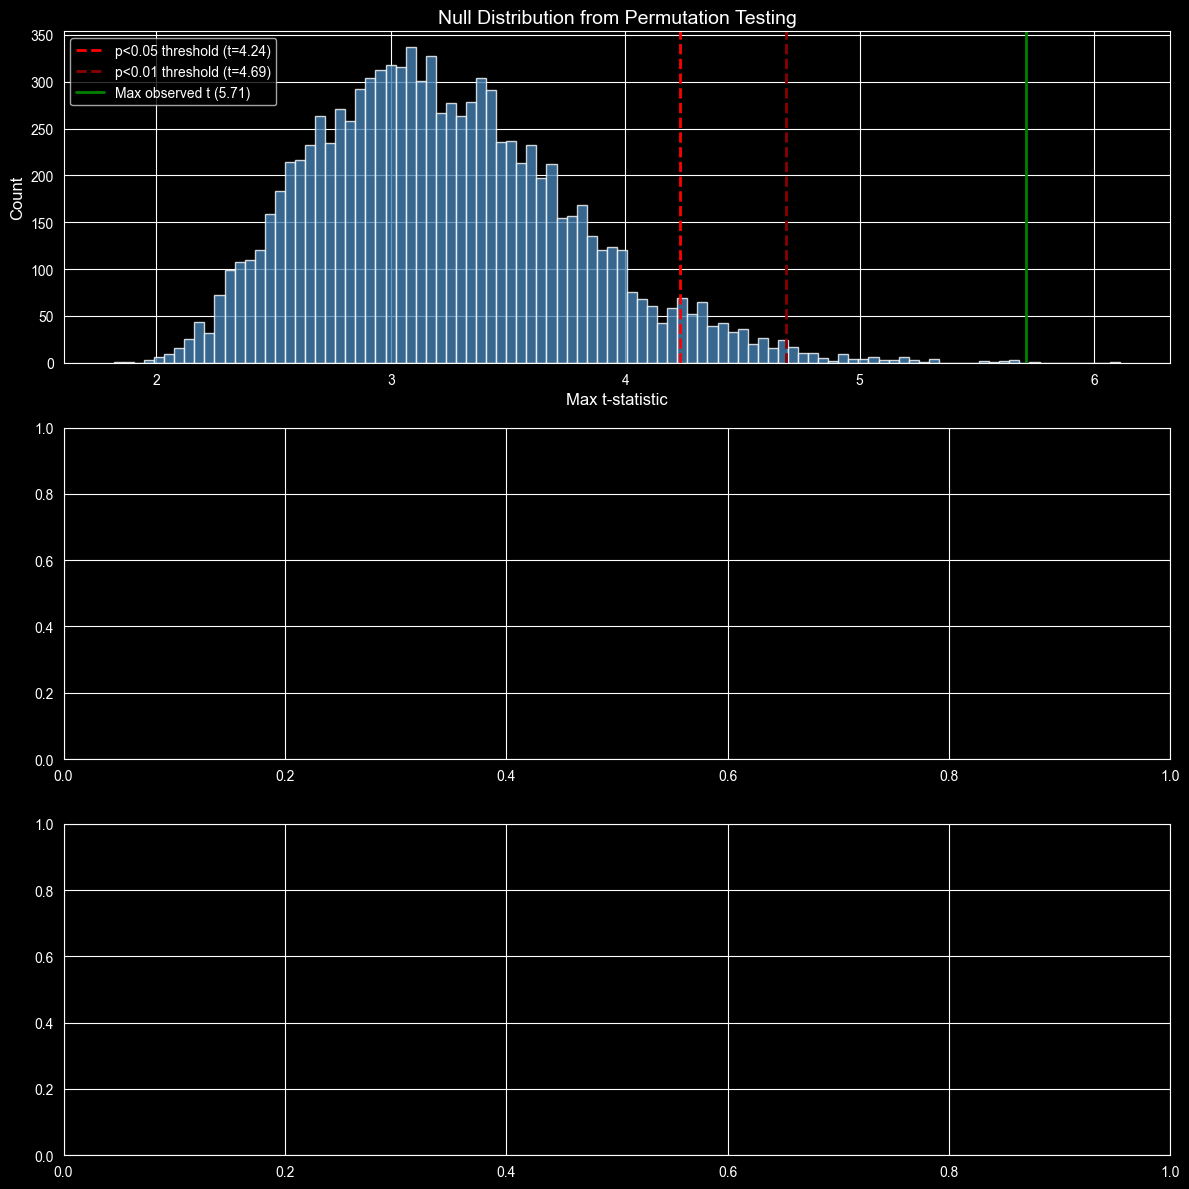

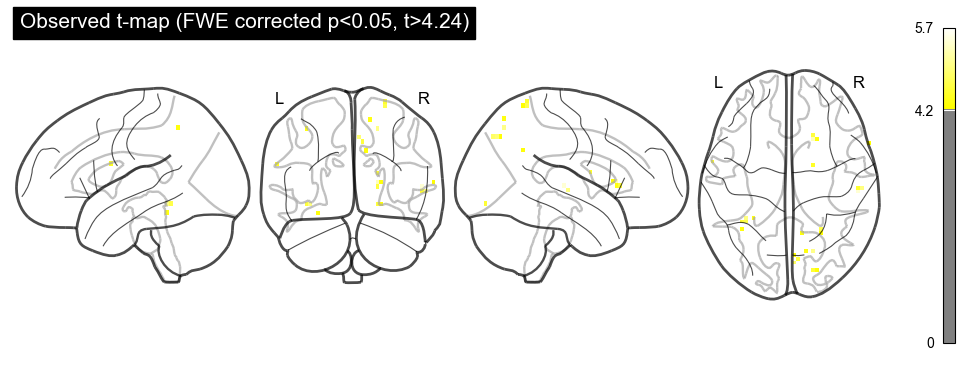

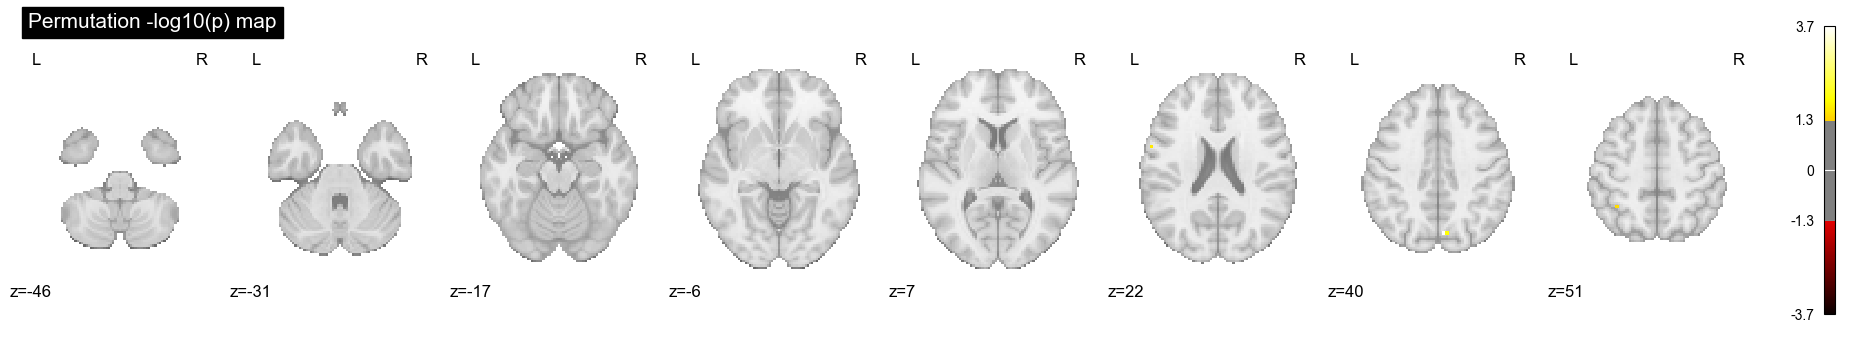

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# --- Plot 1: Null distribution ---
axes[0].hist(null_distribution, bins=100, color="steelblue",
             edgecolor="white", alpha=0.8)
axes[0].axvline(threshold_fwe_05, color="red", linestyle="--",
                linewidth=2, label=f"p<0.05 threshold (t={threshold_fwe_05:.2f})")
axes[0].axvline(threshold_fwe_01, color="darkred", linestyle="--",
                linewidth=2, label=f"p<0.01 threshold (t={threshold_fwe_01:.2f})")
axes[0].axvline(observed_t_masked.max(), color="green", linestyle="-",
                linewidth=2, label=f"Max observed t ({observed_t_masked.max():.2f})")
axes[0].set_xlabel("Max t-statistic", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Null Distribution from Permutation Testing", fontsize=14)
axes[0].legend()

plt.tight_layout()
plt.show()

# --- Plot 2: Thresholded t-map ---
plotting.plot_glass_brain(
    observed_t_map,
    threshold=threshold_fwe_05,
    colorbar=True,
    title=f"Observed t-map (FWE corrected p<0.05, t>{threshold_fwe_05:.2f})",
    display_mode="lyrz",
    cmap="hot"
)

# --- Plot 3: Log p-value map ---
plotting.plot_stat_map(
    log_p_map,
    threshold=1.3,              # -log10(0.05) ≈ 1.3
    colorbar=True,
    title="Permutation -log10(p) map",
    display_mode="z",
    cut_coords=8,
    cmap="hot"
)

plt.show()


In [15]:
import sys
sys.path.append("..")

import numpy as np

import lib.mni_to_atlas as mni_to_atlas

mni_to_atlas._ATLASES_PATH = "../lib"

atlas = mni_to_atlas.AtlasBrowser("AAL3")



In [16]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    observed_t_map, stat_threshold=threshold_fwe_05, cluster_threshold=1
)

pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

regions = []

for p in pos:
    projected_coords = atlas.project_to_nearest(p)
    projected_regions = atlas.find_regions(projected_coords)

    regions.append(*projected_regions)

regions

['Fusiform_R', 'Frontal_Inf_Tri_L', 'Temporal_Pole_Sup_L', 'Fusiform_R']

In [17]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    observed_t_map, stat_threshold=threshold_fwe_01, cluster_threshold=2
)

pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

regions = []

for p in pos:
    projected_coords = atlas.project_to_nearest(p)
    projected_regions = atlas.find_regions(projected_coords)

    regions.append(*projected_regions)

regions

['Fusiform_R']

In [18]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    log_p_map, stat_threshold=threshold_fwe_01, cluster_threshold=1
)

pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

regions = []

for p in pos:
    projected_coords = atlas.project_to_nearest(p)
    projected_regions = atlas.find_regions(projected_coords)

    regions.append(*projected_regions)

regions

C:\Users\ducat\AppData\Local\Temp\ipykernel_12672\4246473914.py:3: UserWarning: The given float value must not exceed 3.6989697871888323. But, you have given threshold=4.686336372508585.
  table = get_clusters_table(
C:\Users\ducat\AppData\Local\Temp\ipykernel_12672\4246473914.py:3: UserWarning: No clusters found with stat higher than 4.686336372508585
  table = get_clusters_table(


[]